<a href="https://colab.research.google.com/github/Dferrer2405/Prueba-tecnica-naowee--Daniel-Ferrer/blob/main/Caso_1_Prueba_T%C3%A9cnica_Daniel_Ferrer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
print("Path to dataset files:", path)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df=pd.read_csv("/kaggle/input/hotel-booking-demand/hotel_bookings.csv")

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Path to dataset files: /kaggle/input/hotel-booking-demand


In [ ]:
print(df.shape)
#Perfilamiento
  #Data frame
resumen = pd.DataFrame({
    "dtype_pandas": df.dtypes,
    "n_unicos": df.nunique(),
    "ejemplo": df.iloc[0]
})
 #Clasificación estadistica
resumen['tipo_estadistico']=[
    'Cat_Nom',
    'Cat_Nom',
    'Num_Cont',
    'Cat_Ord',
    'Cat_Ord',
    'Cat_Ord',
    'Cat_Ord',
    'Cat_Nom',
    'Cat_Nom',
    'Num_Disc',
    'Num_Disc',
    'Num_Disc',
    'Cat_Nom',
    'Cat_Nom',
    'Cat_Nom',
    'Cat_Nom',
    'Cat_Nom',
    'Num_Disc',
    'Num_Disc',
    'Cat_Nom',
    'Cat_Nom',
    'Num_Disc',
    'Cat_Nom',
    'Cat_Nom',
    'Cat_Nom',
    'Num_Disc',
    'Cat_Nom',
    'Num_Cont',
    'Num_Disc',
    'Num_Disc',
    'Cat_Nom',
    'Cat_Ord'
]
conteo_tipo=resumen['tipo_estadistico'].value_counts()
print(resumen)
conteo_tipo

(119390, 32)
                               dtype_pandas  n_unicos       ejemplo  \
hotel                                object         2  Resort Hotel   
is_canceled                           int64         2             0   
lead_time                             int64       479           342   
arrival_date_year                     int64         3          2015   
arrival_date_month                   object        12          July   
arrival_date_week_number              int64        53            27   
arrival_date_day_of_month             int64        31             1   
stays_in_weekend_nights               int64        17             0   
stays_in_week_nights                  int64        35             0   
adults                                int64        14             2   
children                            float64         5           0.0   
babies                                int64         5             0   
meal                                 object         5           

,count
tipo_estadistico,
Cat_Nom,16
Num_Disc,9
Cat_Ord,5
Num_Cont,2


In [ ]:
#conteo de valores nulos por variable
nulo=pd.DataFrame({'n_null':df.isnull().sum(),
                   'pct_null':df.isnull().sum()/df.shape[0]
                  })
print(nulo[nulo['n_null']!=0].sort_values('n_null',ascending=False))


          n_null  pct_null
company   112593  0.943069
agent      16340  0.136862
country      488  0.004087
children       4  0.000034


In [ ]:
#Conteo de duplicados
Duplicados=df.duplicated().sum()

#Tabla
Info_duplicados=pd.DataFrame([{
    'Duplicados':Duplicados,
    'Porcentaje':Duplicados/df.shape[0]
}])
print(Info_duplicados)

   Duplicados  Porcentaje
0       31994    0.267979


In [ ]:
#Selección de variables categoricas dtype=object
categoricas = df.select_dtypes(include="object")

#Conteo de categorías unicas
cardinalidad=categoricas.nunique()

#Perfilamiento de variables con cardinalidad baja nunique<10
baja_cardinalidad = cardinalidad[cardinalidad<=10]
print(cardinalidad)
print()

#Output: 1) nunique para todos dtype=object y
        #2) frecuencia de categoría para variables con cardinalidad baja
for columna in baja_cardinalidad.index:
    print(columna,'cuenta con',df[columna].nunique(), 'categorias para la variable')
    print(df[columna].value_counts().head())
    print()


#Distribución de variables numericas
subgrupo_numericas=resumen[(resumen['tipo_estadistico']=='Num_Cont')|(resumen['tipo_estadistico']=='Num_Disc')]
variables_numericas=subgrupo_numericas.index.tolist()
df_numericas=df[variables_numericas]
df_numericas.describe()

hotel                        2
arrival_date_month          12
meal                         5
country                    177
market_segment               8
distribution_channel         5
reserved_room_type          10
assigned_room_type          12
deposit_type                 3
customer_type                4
reservation_status           3
reservation_status_date    926
dtype: int64

hotel cuenta con 2 categorias para la variable
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

meal cuenta con 5 categorias para la variable
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

market_segment cuenta con 8 categorias para la variable
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Name: count, dtype: int64

distribution_channel cuenta con 5 categorias para la variable
distribution_channel
TA/TO        97870
Di

,lead_time,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,1.856403,0.103890,0.007949,0.087118,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363
std,106.863097,0.579261,0.398561,0.097436,0.844336,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,18.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,69.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000
75%,160.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,737.000000,55.000000,10.000000,10.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
#Tabla Resumen
resumen_final = pd.DataFrame({
    "dtype_pandas": df.dtypes,
    "tipo_semantico": [ 'Cat_Nom',
    'Cat_Nom',
    'Num_Cont',
    'Cat_Ord',
    'Cat_Ord',
    'Cat_Ord',
    'Cat_Ord',
    'Cat_Nom',
    'Cat_Nom',
    'Num_Disc',
    'Num_Disc',
    'Num_Disc',
    'Cat_Nom',
    'Cat_Nom',
    'Cat_Nom',
    'Cat_Nom',
    'Cat_Nom',
    'Num_Disc',
    'Num_Disc',
    'Cat_Nom',
    'Cat_Nom',
    'Num_Disc',
    'Cat_Nom',
    'Cat_Nom',
    'Cat_Nom',
    'Num_Disc',
    'Cat_Nom',
    'Num_Cont',
    'Num_Disc',
    'Num_Disc',
    'Cat_Nom',
    'Cat_Ord'
    ],
    "n_nulos": df.isnull().sum(),
    "pct_nulos": df.isnull().sum()/df.shape[0],
    "n_unicos": df.nunique(),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
    "media": df.mean(numeric_only=True)
})
resumen_final

,dtype_pandas,tipo_semantico,n_nulos,pct_nulos,n_unicos,min,max,media
adr,float64,Cat_Nom,0,0.000000,8879,-6.38,5400.0,101.831122
adults,int64,Cat_Nom,0,0.000000,14,0.00,55.0,1.856403
agent,float64,Num_Cont,16340,0.136862,333,1.00,535.0,86.693382
arrival_date_day_of_month,int64,Cat_Ord,0,0.000000,31,1.00,31.0,15.798241
arrival_date_month,object,Cat_Ord,0,0.000000,12,NaN,NaN,NaN
arrival_date_week_number,int64,Cat_Ord,0,0.000000,53,1.00,53.0,27.165173
arrival_date_year,int64,Cat_Ord,0,0.000000,3,2015.00,2017.0,2016.156554
assigned_room_type,object,Cat_Nom,0,0.000000,12,NaN,NaN,NaN
babies,int64,Cat_Nom,0,0.000000,5,0.00,10.0,0.007949
booking_changes,int64,Num_Disc,0,0.000000,21,0.00,21.0,0.221124


Caso 1
  1. Perfilado de datos:

    1.1. Identificación de variables y tipo:

      Se cuentan con 119390 observaciones y 32 variables en forma de filas y columnas respectivamente. La información está organizada de forma longitudinal. En la tabla se ubican el Dtype para cada variable junto con el numero de observaciones unicas. Además se clasifica cada variable como:

      - Numerica Continua = Num_Cont
      - Numerica Discreta = Num_Disc
      - Categorica Nominal = Cat_Nom
      - Categorica Ordinal = Cat_Ord

      La mayoría de variables son categoricas, dentro de estas se incluyen fechas y 2 identificadores "agent" y "company". También se tienen 2 variables logisiticas "is_canceled" y "is_repeated_guest". El resto de variables ofrecen información que permiten perfilar al cliente o ubicación de la reserva.

    1.2. Valores Nulos:

      De las variables mencionadas solo 4 de ellas cuentan con observaciones vacias. La variable "company" está casi completamente vacía, razón por la que se podría considerar convertir la variable en una logistica donde simplemente identifique si cuenta con empresa o no.

      La variable agent se encuentra parcialmente vacía también pero sigue siendo manejable, mientras que la falta de observaciones en "country" y "children" es marginal.

    1.3. Duplicados
      Se encontraron 31994 observaciones prefectamente duplicadas que representan poco más de 1/4 de las observaciones totales.

    1.4. Cardinalidad
      Se observa que la mayoría de variables categoricas cuentan con una cardinalidad baja o manejable, yendo de 2 a 5 categorías unicas. Las unicas excepciones a esto son las variables asociadas al tipo de habitación y la variable "country".
      
      Las variables de tipo de habitación peresentan 10 y 12 categorías unicas lo cual es alto pero manejable, por otro lado, la variable "country" cuenta con 177 paises diferentes registrados lo que la vuelve inmanejable y puede llegar a necesitar algún tipo de agrupación.

    1.5. Distribución de variables numericas
      Al generar una tabla que recopile los estadisticos descriptivos de las variables designadas como numericas, se observa que variables como "lead_time", "adults", "previous_bookings_not_cancelled", "days in waiting list" y "adr" presentan valores maximos desproporcionados, tremendamente alejados de su media. Estos valores pueden corresponder a outliers o errores y se modificaran para evitar sesgos en el analisis.
      Adicionalmente, se observa que la variable "adr" cuenta con un valor minimo negativo el cual puede corresponder a un desembolso.

In [ ]:
#Eliminación de duplicados
df=df.drop_duplicates()

#Llenar valores vacios
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna('no_info')
df['children'] = df['children'].fillna(0)

#Droppear columna 'company'
df.drop('company',axis=1,inplace=True)

#Eliminación de reservas vacias
df['num_huespedes']=df['adults']+df['children']+df['babies']
reservas_vacias=df[df['num_huespedes']==0]
print('hay'+' '+str(reservas_vacias.shape[0])+' '+'reservas vacias')

#dataframe con reservas no vacias
df=df[df['num_huespedes']>0]

#eliminación valores negativos
df=df[df['adr']>0]
print('tras la eliminación de duplicados, reservas vacias y desembolsos se tienen '+str(df_pos.shape[0])+' observaciones')

#columna de fecha
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)
df['arrival_month_num']=df['arrival_date'].dt.month
df["arrival_quarter"] = df["arrival_date"].dt.quarter
df["arrival_dayofweek"] = df["arrival_date"].dt.dayofweek
df_clean=df.copy()

hay 166 reservas vacias
tras la eliminación de duplicados, reservas vacias y desembolsos se tienen 85586 observaciones


In [ ]:
print('En la siguiente tabla se resumen los cambios y transformaciones realizadas:')
print()
resumen_transformaciones=pd.DataFrame({
    'Variable u objeto':['duplicados', 'agent', 'children','country', 'company','num_huespedes=0','arrival_date'],
    'acción':['eliminados','llenar vacios con 0','vacios llenados con 0','vacios llenados no_info','eliminada','eliminadas','fecha unificada construida'],
    'justificación':['Valor analitico nulo','representan no paso por agencias','nulos=sin niños','conservar masa','94% nulos y mucha granularidad','no representan demanda real','necesaria para analisis temporal']
})
resumen_transformaciones

En la siguiente tabla se resumen los cambios y transformaciones realizadas:



,Variable u objeto,acción,justificación
0,duplicados,eliminados,Valor analitico nulo
1,agent,llenar vacios con 0,representan no paso por agencias
2,children,vacios llenados con 0,nulos=sin niños
3,country,vacios llenados no_info,conservar masa
4,company,eliminada,94% nulos y mucha granularidad
5,num_huespedes=0,eliminadas,no representan demanda real
6,arrival_date,fecha unificada construida,necesaria para analisis temporal


Caso 1
    
    1.2 Limpieza y transformación:
      
      1.2.1 Eliminación de duplicados: Se eliminaron 31994 filas duplicadas, manteniendo 87396 observaciones. Esto se hace con el fin de evitar que observaciones duplicadas sesguen el analisis a futuro.

      1.2.2 Valores Vacios: Con el fin de mantener uniforme el tipo de datos, se llenaron las variables "agent" y "children" con 0s, y la variable "company" con strings. La decisión para la variable "children" es intuitiva además de que solo reemplaza 4 observaciones. Para la variable "agent" tiene sentido mantenerla ya que refleja que los huespedes no pasaron por agencia de viajes, despreciarlo sería perder información.

      1.2.3 Eliminación columna 'company': Debido a su alta granularidad y porcentaje de valores nulos se decidió eliminar la variable del analisis.

      1.2.4 Eliminación de reservas vacias: Se eliminaron 166 observaciones que no registraban ningún tipo de huesped ya que, logicamente, no hay reserva sin huesped.
      
      1.2.5 Construcción de fecha: A partir de las variables "arrival_date_year", "arrival_date_month" y "arrival_date_day_of_month" se creó una columna con contiene la fecha completa con formato YY-MM-DD. Esto se hace con el fin de pode realizar analisis de linea de tiempo como estacionalidad y tendencia de la variable objetivo.

(85586, 36)


<function matplotlib.pyplot.clf() -> 'None'>

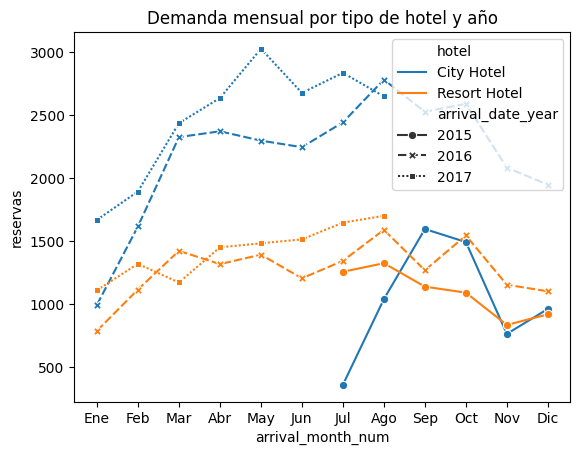

In [ ]:
print(df_clean.shape)
#comportamiento de demanda por año y hotel
demanda_mensual = (df_clean.groupby(["arrival_date_year", "arrival_month_num", "hotel"])
    .size()
    .reset_index(name="reservas"))
sns.lineplot(
    data=demanda_mensual,
    x="arrival_month_num", y="reservas",
    hue="hotel", style="arrival_date_year",
    markers=True)
plt.title("Demanda mensual por tipo de hotel y año")
plt.xticks(range(1,13), ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
plt.clf

Caso 1

    1.3 Analisis exploratorio
      1.3.1 Estacionalidad de la demanda: En este caso se toma como demanda la cantidad de reservas realizadas, es decir, el conteo de observaciones para dado periodo de tiempo.
      Se graficó el comportamiento mensual de la demanda para los diferentes tipos de hoteles y años. Abarca el horizonte de tiempo desde Julio de 2015 a Agosto de 2017.
      Lo primero que se puede observar del comportamiento de la demanda es que, indiscutiblemente, ha tendido a aumentar anualmente. La serie además no es homogenea a lo largo del año, cuenta con una estacionalidad muy pronunciada al rededor de las temporadas de verano (Julio-Agosto) y de invierno (noviembre-febrero).
      Los hoteles de ciudad enfrentan una demanda consistentemente mas alta que los hoteles de resort. Esto se puede deber a que los hoteles de resort son más dependientes de temporada de verano y vacaciones. Ya que, porcentualmente, tienen su mayor incremento en los meses de Julio y Agosto.
      Por otro lado, los hoteles de ciudad enfrentan temporadas bajas entre noviembre y febrero. La alta demanda de los hoteles de ciudad se puede explicar ya que no atienden unicamente turismo vacacional si no también de negocios. Esto podría explicar por qué la demanda de estos hoteles es consitentemente mayor a la de los resorts.

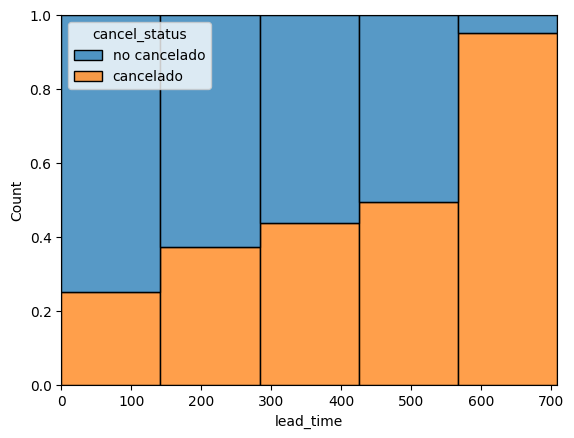

In [ ]:
#relación cancelacion y lead time
df_clean['cancel_status']=np.where(df_clean['is_canceled']==1,'cancelado','no cancelado')
sns.histplot(
    data=df_clean,
    x="lead_time",
    hue="cancel_status",
    multiple="fill",
    bins=(5))
plt.show()

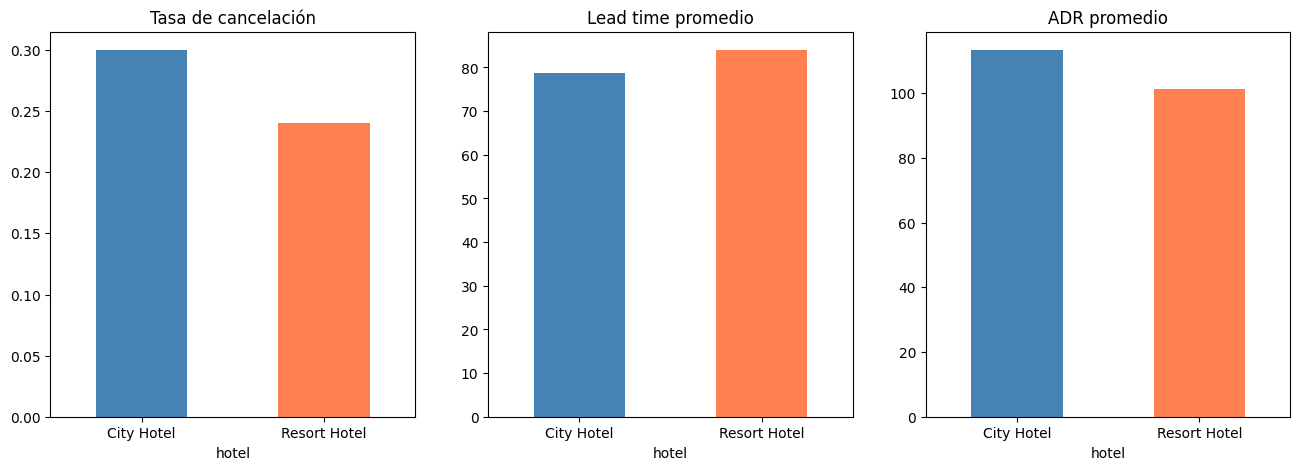

In [ ]:
#relación cancelacion y tipo de hotel
resumen_hotel = df_clean.groupby("hotel").agg(
    tasa_cancelacion=("is_canceled", "mean"),
    lead_time_medio=("lead_time", "mean"),
    adr_medio=("adr", "mean"),
).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metricas = ["tasa_cancelacion", "lead_time_medio", "adr_medio"]
titulos = ["Tasa de cancelación", "Lead time promedio", "ADR promedio"]

for ax, metrica, titulo in zip(axes, metricas, titulos):
    resumen_hotel[metrica].plot(kind="bar", ax=ax, color=["steelblue", "coral"])
    ax.set_title(titulo)
    ax.set_xticklabels(resumen_hotel.index, rotation=0)


                tasa_cancelacion  n_reservas
market_segment                              
Undefined               1.000000           2
Online TA               0.355664       51245
Groups                  0.278602        4720
Aviation                0.198198         222
Offline TA/TO           0.149116       13627
Direct                  0.147857       11572
Corporate               0.122099        4136
Complementary           0.080645          62
0.5987544691888861


Text(0.5, 1.0, 'Volumen de reservas por segmento')

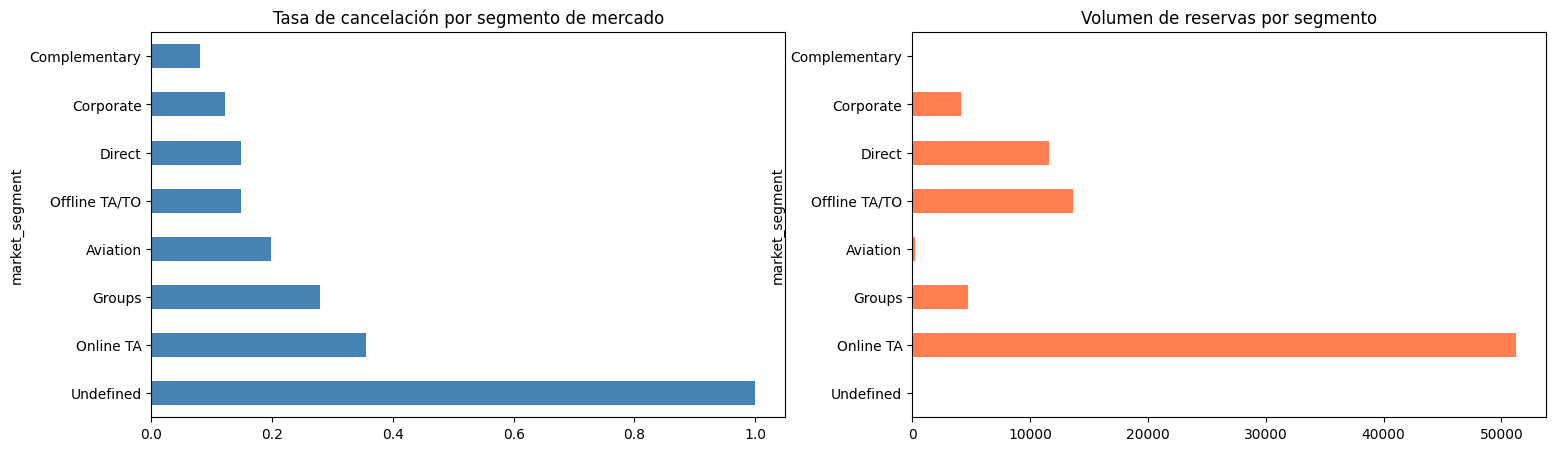

In [ ]:
#segmentos de mercado y cancelación
resumen_segmento = (
    df_clean.groupby("market_segment")["is_canceled"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "tasa_cancelacion", "count": "n_reservas"})
    .sort_values("tasa_cancelacion", ascending=False)
)
print(resumen_segmento)
print(df_clean[df_clean['market_segment']=='Online TA'].shape[0]/df_clean.shape[0])
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

resumen_segmento["tasa_cancelacion"].plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Tasa de cancelación por segmento de mercado")
resumen_segmento["n_reservas"].plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Volumen de reservas por segmento")

                      tasa_cancelacion  n_reservas
distribution_channel                              
Undefined                     0.800000           5
TA/TO                         0.312522       68280
GDS                           0.203390         177
Direct                        0.150000       12220
Corporate                     0.128059        4904


Text(0.5, 1.0, 'Volumen de reservas por canal de distribución')

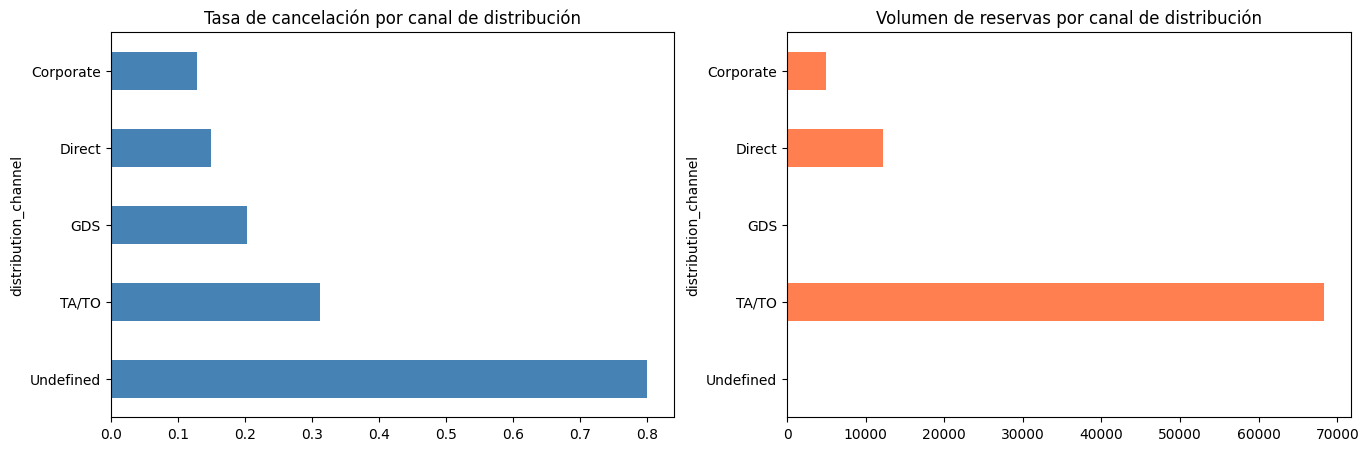

In [ ]:
#canales de distribución y cancelación
resumen_canal = (
    df_clean.groupby("distribution_channel")["is_canceled"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "tasa_cancelacion", "count": "n_reservas"})
    .sort_values("tasa_cancelacion", ascending=False)
)
print(resumen_canal)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
resumen_canal["tasa_cancelacion"].plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Tasa de cancelación por canal de distribución")
resumen_canal["n_reservas"].plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Volumen de reservas por canal de distribución")

                       adr_medio  adr_variabilidad
distribution_channel                              
GDS                   123.036893       1538.339993
Direct                115.961230       3471.621717
TA/TO                 109.828762       2348.179368
Corporate              70.987190       1025.125756
Undefined              46.240000       2118.713000


/tmp/ipykernel_8931/1649436858.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(["No cancelada", "Cancelada"])


Text(0.5, 1.0, 'ADR según resultado de la reserva')

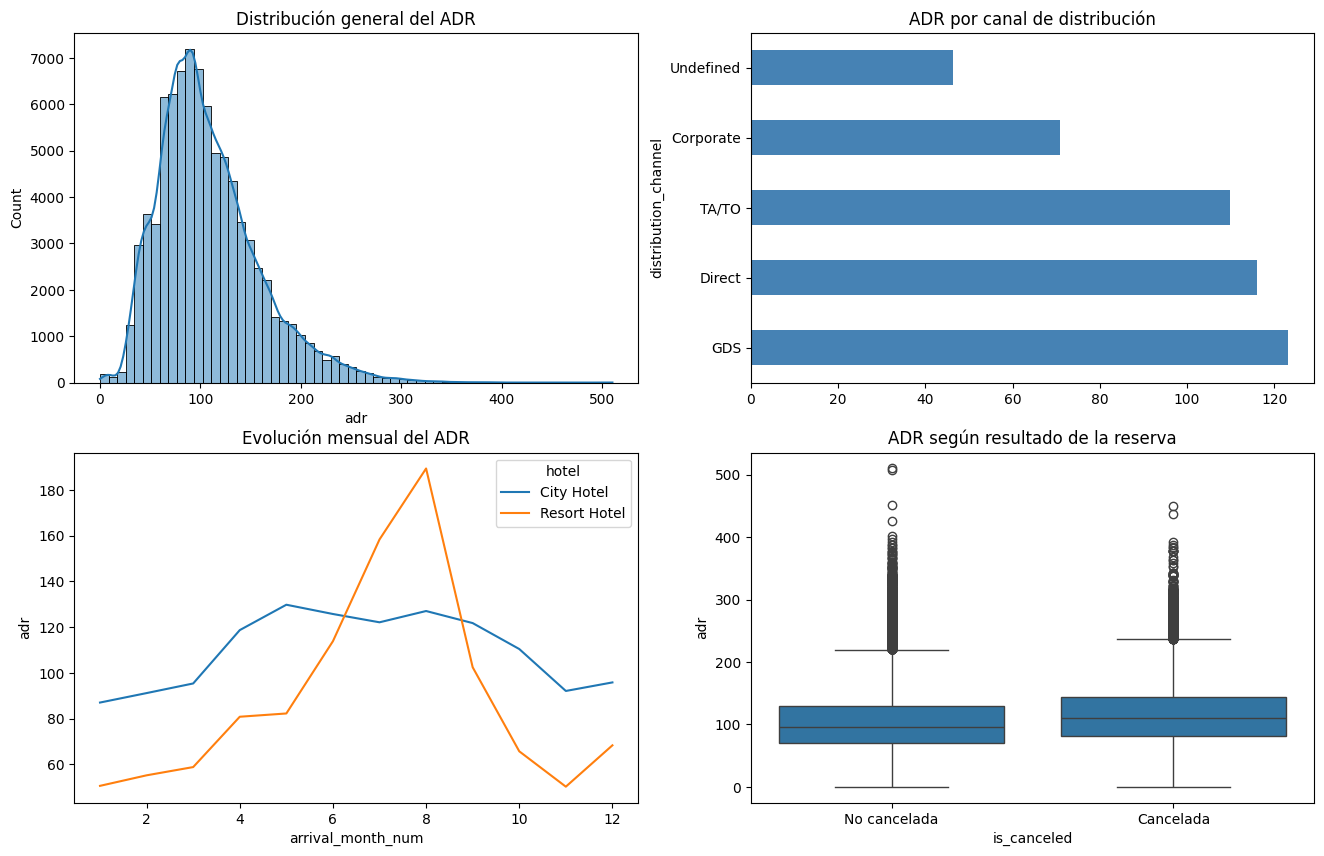

In [ ]:
#distribución del adr, segregación por hotel, relación con cancelación y canales de distribución
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

tarifas_adr=df_clean[(df_clean['adr']>0)&(df_clean['adr']<1000)]

#distribución general
sns.histplot(tarifas_adr["adr"], bins=60, ax=axes[0,0], kde=True)
axes[0,0].set_title("Distribución general del ADR")

#adr mensual promedio por hotel
adr_mensual = (
    tarifas_adr.groupby(["arrival_month_num", "hotel"])["adr"]
    .mean().reset_index()
)
sns.lineplot(
    data=adr_mensual, x="arrival_month_num", y="adr",
    hue="hotel", ax=axes[1,0], markers=True
)
axes[1,0].set_title("Evolución mensual del ADR")

#adr por canal de distribución
adr_canal=(tarifas_adr.groupby("distribution_channel")["adr"]
    .agg(["mean", "var"])
    .rename(columns={"mean": "adr_medio", "var": "adr_variabilidad"})
    .sort_values("adr_medio", ascending=False)
)
axes[0,1].set_title("ADR por canal de distribución")
adr_canal['adr_medio'].plot(kind="barh", ax=axes[0,1], color="steelblue")
print(adr_canal)

#relación adr cancelación
sns.boxplot(data=tarifas_adr, x="is_canceled", y="adr", ax=axes[1,1])
axes[1,1].set_xticklabels(["No cancelada", "Cancelada"])
axes[1,1].set_title("ADR según resultado de la reserva")


Caso 1

    1.3 Analisis exploratorio
        Sobre la relación de las cancelaciones con las diferentes variables categoricas se obtiene lo siguiente:
        - Lead time: la diferencia entre la fecha de reserva y de llegada, tiene una relación directa y positiva con la tasa de cancelación. Describe un comportamiento casi exponencial donde la tasa de cancelación aumenta a tasas marginalmente crecientes por cada aumento del lead time. El mensaje es evidente, entre más anticipación se tenga al realizar la reserva más tiempo tiene el cliente para encontrar mejores ofertas o arrepentirse. Por otro lado las reservas realizadas con poco tiempo de antelación tienen una tasa de cancelación significativamente menor.

        - Hotel: La tasa de cancelación no parece mantener una diferencia significativa entre los distintos tipos de hoteles. Esto se cumple también para otras variables como el lead time y la adr. La unica diferencia real entre los tipos de hotel parece ser el volumen de demanda como se estableció previamente.

        - Segmento de mercado: En la grafica se evidencia que el segmento categorizado como "undefined" cuenta con una tasa de cancelación del 100%. Esto sería un hallazgo importante, sin embargo, solo hay 3 registros de esta categoría en total por lo que no son relevantes. Por otro lado la categoría "Online TA" presenta la mayor acumulación de cancelaciones con un 35% y cerca del 60% del total de reservas. Esta categoría representa las reservas a través de agencias online, este tipo de servicios suelen ofrecer como mayor appeal la caza de precios bajos y por lo tanto tienden a reducir la fricción al momento de cancelar reservas con tarifas bajas o nulas. Finalmente, segmentos como Corporate o Group tienen la menor tasa de cancelación, esto se puede atribuir a que los viajes corporativos son responsabilidades laborales por lo que la cancelación no es una decisión individual al igual que pasa con los viajes grupales donde el compromiso con el grupo y el coste de organizar actua como detrimento a la cancelación.

        - Canales de distribución: Los canales de distribución con tasas de cancelación mas altas son las agencias de viaje y los directos. Al igual que con el segmento de mercado, las agencias de viaje recogen mas de la mitad de la demanda y la mayoría de cancelaciones, en este caso un 31%. Las reservas directas ocupan un 20% pero representan una parte diminuta del mercado. Gracias a la descomposición por segmentos sabemos que la mayor parte de las cancelaciones de agencias se deben a las particularidades de las agencias en linea.

        - ADR: Se observa que el ADR tiene una distribución asimetrica hacia la derecha la cual se puede atribuir a los picos mensuales que sufren los hoteles de tipo resort entre Junio y Agosto. En estos meses la tarifa de los hoteles tipo resort se dispara mas allá del doble y dado que la demanda de estos hoteles es, incluso en temporada alta, menor que la de los hoteles de ciudad se consiguen tarifas altas con poca frecuencia lo que causa esta asimetría. Respecto a los canales de distribución, las agencias de viaje, reservas directas y GDR ocupan los valores de ADR promedio más altos. De estos 3 solo las agencias de viaje ocupan una parte significativa de la demanda, además se observa que son el segundo canal con mayor varianza. Esto apoya la teoría de que la cancelación alta en los segmentos de agencias digitales se debe a las bajas barreras para cancelación y alta volatilidad de los valores, que permiten a aquellos con un mayor lead time tomar cancelar reservaciones previas por mejores ofertas. Por ultimo, el diagrama de caja nos revela que las reservas canceladas si suelen tener tarifas ligeramente mayores que las no canceladas. Esto sugiere que si puede haber un efecto de busqueda de mejor precio, aunque la diferencia no es lo suficientemente amplia como para afirmarlo de forma intuitiva.

In [ ]:

#Se observa la variable lead time en 2 poblaciones: reservas canceladas y no canceladas
canceladas = df_clean[df_clean["is_canceled"] == 1]["lead_time"]
no_canceladas = df_clean[df_clean["is_canceled"] == 0]["lead_time"]

#prueba de normalidad
stat1, p1 = stats.normaltest(canceladas)
stat2, p2 = stats.normaltest(no_canceladas)
print('PRUEBA DE NORMALIDAD')
print(f"p-valor canceladas:     {p1:.4f}")
print(f"p-valor no canceladas:  {p2:.4f}")

#prueba de hipotesis no parametrica
stat, p_value = stats.mannwhitneyu(
    canceladas,
    no_canceladas,
    alternative="greater")
print('PRUEBA DE INDEPENDENCIA MANN WHITNEY')
print(f"Estadístico U: {stat:.0f}")
print(f"p-value:       {p_value:.6f}")
print()
#prueba chi cuadrado
chi2, p_valor, dof, freq_esp = stats.chi2_contingency(
    pd.crosstab(df["distribution_channel"], df["is_canceled"])
)
print('PRUEBA DE INDEPENDENCIA CHI CUADRADO')
print(f"estadistico = {chi2:.2f}, gl = {dof}, p-value = {p_valor:.6f}")

PRUEBA DE NORMALIDAD
p-valor canceladas:     0.0000
p-valor no canceladas:  0.0000
PRUEBA DE INDEPENDENCIA MANN WHITNEY
Estadístico U: 947575542
p-value:       0.000000

PRUEBA DE INDEPENDENCIA CHI CUADRADO
estadistico = 3745.79, gl = 4, p-value = 0.000000


Caso 1

    1.4 Pregunta dirigida: ¿Qué factores se asocian con que una reserva se cancele?

      Para responder la pregunta se evaluara la relación de las variables lead time y canal de distribución con la tasa de cancelación a través de pruebas de hipotesis de acuerdo con lo observado en el analisis exploratorio.

        1.4.1 Relación entre lead time y cancelación
      
      Para empezar se evalua la relación con el lead time. En este caso, se hará una prueba de diferencia de medias para verificar que existen diferencias significativas entre el lead time de las reservas canceladas y las no canceladas.
      Antes de realizar la prueba de diferencia, se debe comprobar la normalidad de la variable lead time para ambas poblaciones. Con un p-valor menor a 0.05 para ambas poblaciones, se rechaza la hipotesis nula y se acepta la hipotesis alternativa donde la variable no se distribuye normalmente.
      Ya que se viola el supuesto de normalidad, no se puede hacer uso de una prueba t de student para evaluar las diferencias entre las poblaciones. Por lo tanto se usara la prueba U de Mann Whitney como alternativa no parametrica.
      La prueba de Mann Whitney arroja un p-value menor de 0.05 por lo que se rechaza la hipotesis nula (H0=lead time de canceladas es menor a lead time no canceladas) en favor de la hipotesis alternativa donde el lead time de las reservas canceladas es significativamente mayor que el de las no canceladas.
       
       1.4.2 Relación entre canales de distribución y cancelación
      
      Dado que en este caso la prueba se realiza para 2 variables categoricas sin un valor numerico continuo, se evaluara sobre la distribución chi-cuadrado. Cumple con los supuestos de la prueba ya que cada categoría es mutuamente excluyente. Por sus propiedades, no demanda pruebas de normalidad o varianza, por lo que se puede proceder a hacer la prueba de independencia directamente. En este caso se hará una prueba de frecuencias esperadas como prueba de independencia. La prueba arroja un p-valor menor a 0.05 por lo que se rechaza nuevamente la hipotesis nula y se acepta la hipotesis alternativa que no permite negar asociación entre las variables. Esto va acorde con lo visto en la exploración y deja claro que el canal puede actuar como predictor del comportamiento del cliente.


In [ ]:
#Metricas temporales por hotel
df_clean["total_nights"] = df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]
df_clean["income"] = df_clean["adr"] * df_clean["total_nights"]
bussiness_summary=(df_clean.groupby(["arrival_date_year", "arrival_date_month", "hotel"]
                                    ).agg(num_reservas=('is_canceled','count'),
                                           pctg_cancelación=('is_canceled','mean'),
                                           anticipación_media=('lead_time','mean'),
                                           noches_promedio=('total_nights','mean'),
                                           tarifa_diaria_promedio=('adr','mean'),
                                           ingreso_estimado_promedio=('income','mean')
                                           ).reset_index().rename(
                                               columns={'arrival_date_year':'año',
                                                        'arrival_date_month':'mes',
                                                        'hotel':'tipo_hotel'
                                                        }
                                           ).round(2)
)
bussiness_summary

,año,mes,tipo_hotel,num_reservas,pctg_cancelación,anticipación_media,noches_promedio,tarifa_diaria_promedio,ingreso_estimado_promedio
0,2015,August,City Hotel,1042,0.22,42.37,3.04,88.16,262.72
1,2015,August,Resort Hotel,1327,0.26,74.36,5.51,158.14,853.09
2,2015,December,City Hotel,964,0.23,39.20,3.14,87.48,276.39
3,2015,December,Resort Hotel,921,0.16,39.18,3.30,62.40,209.09
4,2015,July,City Hotel,362,0.63,120.95,3.60,72.90,257.11
5,2015,July,Resort Hotel,1259,0.22,69.00,5.20,128.49,661.96
6,2015,November,City Hotel,766,0.17,42.98,3.09,76.88,237.00
7,2015,November,Resort Hotel,837,0.13,29.46,3.66,47.47,176.68
8,2015,October,City Hotel,1495,0.19,46.71,2.89,99.16,287.00
9,2015,October,Resort Hotel,1093,0.13,71.58,4.01,59.34,242.60


In [ ]:
#leakage variable: reservation status
reservation_status_leak=df_clean.groupby('reservation_status')['is_canceled'].value_counts(normalize=True)
reservation_status_leak

,,proportion
reservation_status,is_canceled,
Canceled,1,1.0
Check-Out,0,1.0
No-Show,1,1.0


Caso 1

    1.6 Pregunta dirigida: Riesgos para modelos futuros
      A riesgo de errar en conceptos debido a la falta de experiencia en temas de machine learning, el leakage podría venir de variables que registran el resultado que se pretende predecir o de variables que no se pueden poseer al momento de predecir.

      En el primer caso se debería excluir directamente la variables "reservation status" ya que no es más que otra categorización de la variable que se pretende predecir "is_canceled". Siendo canceled y no-show recategorizaciones de las reservas canceladas como se puede ver en la taba arriba.

      El segundo caso se podría debatir la exclusión de la variable adr, este es un valor post-evento que promedia todas las transacciones a lo largo de las noches. Es información util pero no se especifica si esta información corresponde a el valor negociado al momento de la reserva o al momento de cierre de registro. Estos valores pueden diferir por consumos extra durante la estadía o renegociaciones. Por esta razón, ante el desconocimiento de si opera como variable previa o posterior al evento que se pretende predecir, se debería usar con cuidado y documentar la incertidumbre.

      Por ultimo, los datos tienen cobertura parcial de los años 2015 y 2017, siendo el unico año completo 2016. Esto puede ser un problema ya que dificulta reconocer cambios en los patrones de cancelación para meses especificos en los que la cobertura no coincide.